# Convergence criterion experiment

This notebook studies the early-stopping behaviour of the variational-inference
convergence criteria in `treeflow.vi.convergence_criteria`. We:

1. Fit the carnivores model several times with **both** a mean-field and a
   full-rank approximation, with early stopping **disabled**, recording the
   convergence diagnostics (and a sample of parameter values) at every iteration.
2. **Back-calculate**, for each run, the `rtol`/`atol` thresholds — for both the
   loss criterion ([`RelativeLossNotDecreasing`](../treeflow/vi/convergence_criteria/relative_loss_not_decreasing.py))
   and the parameter criterion ([`ParametersNotChanging`](../treeflow/vi/convergence_criteria/parameters_not_changing.py)) —
   that *would* have triggered convergence, and at which iteration.

The back-calculation properly accounts for the `min_consecutive` parameter: a
threshold only fires once the diagnostic stays below it for `min_consecutive`
**consecutive** steps. So the threshold needed to stop at iteration $t$ is the
*maximum* of the diagnostic over the trailing window of `min_consecutive` steps
ending at $t$ — not just its value at $t$.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow_probability as tfp

import treeflow
from treeflow import float_constant as c
from treeflow.evolution.substitution import HKY, get_transition_probabilities_tree
from tensorflow_probability.python.distributions import Gamma, LogNormal, Dirichlet
from treeflow.distributions import (
    DiscretizedDistribution, DiscreteParameterMixture, LeafCTMC, SampleWeighted, Yule,
)
from treeflow.vi import (
    fit_fixed_topology_variational_approximation,
    RobustOptimizer,
    LossAndParametersNotChanging,
    plot_parameter_traces,
)
from treeflow.model.approximation.mean_field import (
    get_fixed_topology_mean_field_approximation,
)
from treeflow.model.approximation.full_rank import (
    get_fixed_topology_full_rank_approximation,
)

%matplotlib inline

/Users/christiaanswanepoel/.pyenv/versions/3.11.12/envs/treeflow/lib/python3.11/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.0.1)/charset_normalizer (3.4.5) doesn't match a supported version!
  warnings.warn(


Silencing TensorFlow...


## Model

The same carnivores HKY + Yule model used in `carnivores.ipynb`.

In [2]:
tree = treeflow.convert_tree_to_tensor(
    treeflow.parse_newick("demo-data/carnivores.newick")
)
alignment = treeflow.Alignment("demo-data/carnivores.fasta").get_compressed_alignment()
pattern_counts = alignment.get_weights_tensor()
subst_model = HKY()
site_category_count = 4


def build_sequence_dist(tree, kappa, frequencies, site_gamma_shape):
    unrooted_tree = tree.get_unrooted_tree()
    site_rate_distribution = DiscretizedDistribution(
        category_count=site_category_count,
        distribution=Gamma(concentration=site_gamma_shape, rate=site_gamma_shape),
    )
    transition_probs_tree = get_transition_probabilities_tree(
        unrooted_tree,
        subst_model,
        rate_categories=site_rate_distribution.normalised_support,
        frequencies=frequencies,
        kappa=kappa,
    )
    return SampleWeighted(
        DiscreteParameterMixture(
            site_rate_distribution,
            LeafCTMC(transition_probs_tree, tf.expand_dims(frequencies, -2)),
        ),
        sample_shape=alignment.site_count,
        weights=pattern_counts,
    )


base_model = tfp.distributions.JointDistributionNamed(
    dict(
        birth_rate=LogNormal(c(1.0), c(1.5)),
        tree=lambda birth_rate: Yule(tree.taxon_count, birth_rate, name="tree"),
        kappa=LogNormal(c(0.0), c(2.0)),
        site_gamma_shape=LogNormal(c(0.0), c(1.0)),
        frequencies=Dirichlet(c([2.0, 2.0, 2.0, 2.0])),
        sequences=build_sequence_dist,
    )
)
model = base_model.experimental_pin(
    sequences=alignment.get_encoded_sequence_tensor(tree.taxon_set)
)

/Users/christiaanswanepoel/uni/treeflow/treeflow/distributions/tree/birthdeath/birth_death_contemporary_sampling.py:68: UserWarning: Dummy sampling
  warnings.warn("Dummy sampling")


## Experiment configuration

We run each approximation family `N_RUNS` times (different random seeds) for
`NUM_STEPS` steps, with early stopping disabled.

To record the diagnostics at every iteration we still *attach* a
`LossAndParametersNotChanging` criterion, but give it a `min_num_steps` larger
than the run so it can never actually fire. A custom `trace_fn` records, per
step, only what we need (so the 50k-step traces stay small): the loss, the four
scalar convergence diagnostics, and the variational **locations** (the
unconstrained posterior means) — *not* the full-rank scale matrix.

Both families expose the locations as a single 1-D vector in the **same**
alphabetical-variable order (mean-field per-variable `*_loc` vectors are
concatenated to match how the full-rank builder packs its joint `loc`), so we
can split them into identical per-variable blocks for plotting.

In [3]:
NUM_STEPS = 60000
N_RUNS = 5
WINDOW_SIZE = 1000       # EWMA time-constant shared by both sub-criteria
MIN_CONSECUTIVE = 3     # consecutive sub-threshold steps required to "fire"
MIN_NUM_STEPS = 5000     # warm-up guard: ignore convergence before this step
LEARNING_RATE = 1e-3
SEEDS = list(range(N_RUNS))

FAMILIES = {
    "mean_field": get_fixed_topology_mean_field_approximation,
    "full_rank": get_fixed_topology_full_rank_approximation,
}

# Model variables in alphabetical order — the order the full-rank builder uses
# when it concatenates the per-variable initial values into its joint loc vector.
MODEL_VARS = sorted(["birth_rate", "frequencies", "kappa", "site_gamma_shape", "tree"])

# Probe the per-variable (unconstrained) sizes once from a mean-field build.
_probe, _probe_vd = get_fixed_topology_mean_field_approximation(
    model, topology_pins=dict(tree=tree.topology), init_loc=dict(tree=tree)
)
VAR_SIZES = {mv: int(_probe_vd[f"{mv}_loc:0"].shape[0]) for mv in MODEL_VARS}
del _probe, _probe_vd


def block_slices(var_sizes, order):
    slices, pos = {}, 0
    for mv in order:
        slices[mv] = slice(pos, pos + var_sizes[mv])
        pos += var_sizes[mv]
    return slices


BLOCKS = block_slices(VAR_SIZES, MODEL_VARS)
print("variable sizes:", VAR_SIZES)
print("loc blocks:", {k: (s.start, s.stop) for k, s in BLOCKS.items()})

variable sizes: {'birth_rate': 1, 'frequencies': 3, 'kappa': 1, 'site_gamma_shape': 1, 'tree': 61}
loc blocks: {'birth_rate': (0, 1), 'frequencies': (1, 4), 'kappa': (4, 5), 'site_gamma_shape': (5, 6), 'tree': (6, 67)}


In [4]:
from collections import namedtuple

RunTrace = namedtuple(
    "RunTrace", ["loss", "rel_rate", "loss_ewma", "rel_change", "param_ewma", "loc"]
)


def diagnostic_criterion():
    "A criterion configured never to fire, used purely to trace diagnostics."
    return LossAndParametersNotChanging(
        rtol=1e-12,
        param_atol=1e-12,
        window_size=WINDOW_SIZE,
        min_num_steps=NUM_STEPS + 1,   # never reached -> never stops
        min_consecutive=MIN_CONSECUTIVE,
    )


def _loc_vector(family_name, variables_dict):
    "The variational locations as one vector, in alphabetical-variable order."
    if family_name == "full_rank":
        return variables_dict["full_rank_loc:0"]   # already alphabetical
    return tf.concat([variables_dict[f"{mv}_loc:0"] for mv in MODEL_VARS], axis=0)


def run_once(family_name, approx_fn, seed):
    tf.random.set_seed(seed)
    # Pre-build the approximation so the trace_fn can read its loc variables by
    # name; hand the same objects back to the fitter via approx_fn.
    approx, variables_dict = approx_fn(
        model, topology_pins=dict(tree=tree.topology), init_loc=dict(tree=tree)
    )

    def trace_fn(tq):
        loss_state, param_state = tq.convergence_criterion_state
        return RunTrace(
            loss=tq.loss,
            rel_rate=loss_state.rel_rate,
            loss_ewma=loss_state.average_decrease,
            rel_change=param_state.rel_change,
            param_ewma=param_state.average_change,
            loc=_loc_vector(family_name, variables_dict),
        )

    optimizer = RobustOptimizer(tf.optimizers.Adam(learning_rate=LEARNING_RATE))
    _, trace = fit_fixed_topology_variational_approximation(
        model,
        topologies=dict(tree=tree.topology),
        optimizer=optimizer,
        num_steps=NUM_STEPS,
        convergence_criterion=diagnostic_criterion(),
        approx_fn=lambda *a, **k: (approx, variables_dict),
        trace_fn=trace_fn,
        return_full_length_trace=True,
        init_loc=dict(tree=tree),
        progress_bar=False,
    )
    loc = np.asarray(trace.loc)
    return dict(
        family=family_name,
        seed=seed,
        loss=np.asarray(trace.loss),
        rel_rate=np.asarray(trace.rel_rate),
        loss_ewma=np.asarray(trace.loss_ewma),
        rel_change=np.asarray(trace.rel_change),
        param_ewma=np.asarray(trace.param_ewma),
        param_trace={mv: loc[:, BLOCKS[mv]] for mv in MODEL_VARS},
    )

In [5]:
runs = []
for family_name, approx_fn in FAMILIES.items():
    for seed in SEEDS:
        print(f"Fitting {family_name} (seed={seed}) ...")
        runs.append(run_once(family_name, approx_fn, seed))
print("Done.")

Fitting mean_field (seed=0) ...
Fitting mean_field (seed=1) ...
Fitting mean_field (seed=2) ...
Fitting mean_field (seed=3) ...
Fitting mean_field (seed=4) ...
Fitting full_rank (seed=0) ...
Fitting full_rank (seed=1) ...
Fitting full_rank (seed=2) ...
Fitting full_rank (seed=3) ...
Fitting full_rank (seed=4) ...
Done.


Fitting mean_field (seed=1) ...


Fitting full_rank (seed=0) ...


Fitting full_rank (seed=1) ...


Done.


### ELBO trajectories

Final loss values and trajectories for every run.

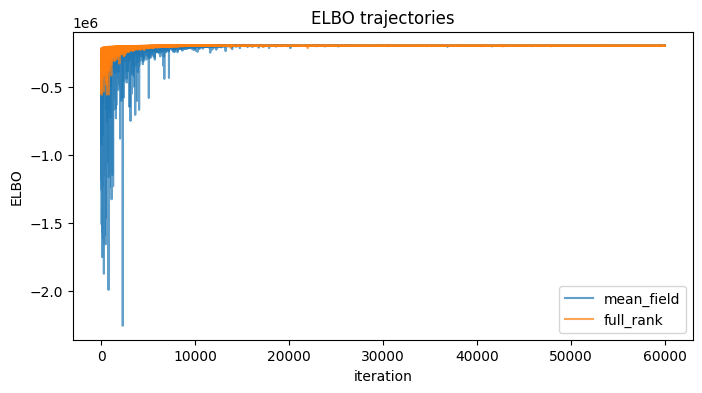

In [6]:
colors = {"mean_field": "C0", "full_rank": "C1"}
fig, ax = plt.subplots(figsize=(8, 4))
for r in runs:
    ax.plot(-r["loss"], color=colors[r["family"]], alpha=0.7,
            label=r["family"] if r["seed"] == 0 else None)
ax.set_xlabel("iteration")
ax.set_ylabel("ELBO")
ax.legend()
ax.set_title("ELBO trajectories")
plt.show()

### Sampled parameter trajectories

One subplot per run. Within each we draw a representative sample of the
variational locations via `plot_parameter_traces(..., sample=True, ax=ax)`: one
coordinate per scalar variable, `frequencies[0]`, and the **root plus two
internal-node** coordinates for the tree (the root is the last node-height
coordinate). This is the enhanced sampled layout of
`treeflow.vi.plot_parameter_traces` — full-rank packs everything into one `loc`
vector, which we split into the same named blocks so both families plot
identically.

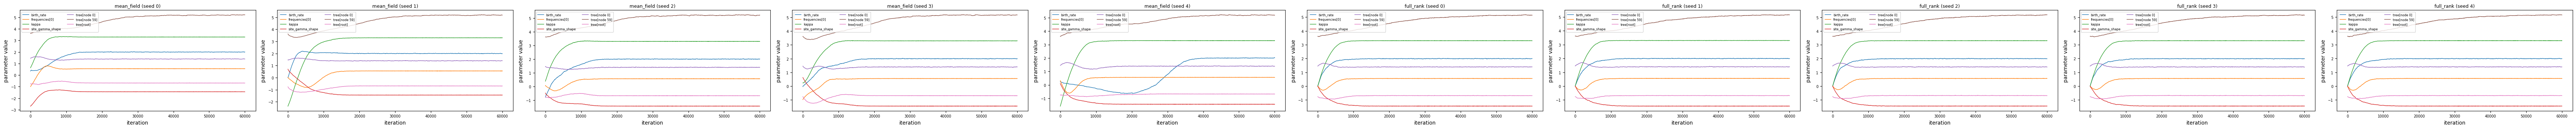

In [7]:
n = len(runs)
ncols = n
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(7 * ncols, 3.6 * nrows), squeeze=False)
flat_axes = axes.ravel()
for r, ax in zip(runs, flat_axes):
    plot_parameter_traces(
        r["param_trace"], sample=True, ax=ax,
        title=f'{r["family"]} (seed {r["seed"]})',
    )
for ax in flat_axes[n:]:
    ax.set_visible(False)
fig.tight_layout()
plt.show()

## Back-calculating the thresholds

For a diagnostic series $d[t]$ and a threshold $T$, the criterion (with
`min_consecutive = k`) declares convergence at the first step $t$ where
$d[s] < T$ for all $s$ in the trailing window $[t-k+1, t]$. Equivalently it
fires at $t$ once

$$\text{wmax}[t] \;=\; \max_{t-k+1 \le s \le t} d[s] \;<\; T.$$

So:

- **`wmax[t]`** is the threshold you would need to set in order to stop *exactly*
  at iteration $t$ (assuming you had not already stopped earlier).
- The running minimum **`frontier[t] = min_{s \le t} wmax[s]`** is the *smallest*
  threshold that would have stopped the run *by* iteration $t$ — the
  threshold ↔ stopping-iteration trade-off curve.

We mirror the criterion's guards: a step that is ineligible to satisfy the
condition (a non-finite diagnostic, or a step where the loss EWMA is negative —
i.e. the ELBO is worsening — which the relative-loss criterion explicitly
excludes) is given an effective value of $+\infty$ so it can never count toward a
satisfying window. We also apply the `min_num_steps` warm-up guard: convergence
is ignored before step `MIN_NUM_STEPS`. This matters because the EWMA is
initialised at 0 and is biased low for the first $\sim$`window_size` steps, which
would otherwise let any loose threshold "fire" spuriously at the very start.

In [8]:
def windowed_max(diag, k, valid=None):
    "Trailing max over a window of `k` steps (np.inf where the window is invalid)."
    d = np.asarray(diag, dtype=float).copy()
    if valid is not None:
        d[~np.asarray(valid, dtype=bool)] = np.inf
    n = len(d)
    out = np.full(n, np.inf)
    for t in range(k - 1, n):
        out[t] = d[t - k + 1 : t + 1].max()
    return out


def stop_iteration(wmax, threshold, min_num_steps=0):
    "First iteration at which `threshold` would fire (or None)."
    fires = wmax < threshold
    if min_num_steps:
        fires[:min_num_steps] = False
    return int(np.argmax(fires)) if fires.any() else None


# (name, kind, accessor returning (diagnostic, validity mask)) for each
# threshold the two criteria expose.
def _loss_rtol(r):
    return r["rel_rate"], np.isfinite(r["rel_rate"]) & (r["loss_ewma"] >= 0)

def _loss_atol(r):
    return r["loss_ewma"], np.isfinite(r["loss_ewma"]) & (r["loss_ewma"] >= 0)

def _param_rtol(r):
    return r["rel_change"], np.isfinite(r["rel_change"])

def _param_atol(r):
    return r["param_ewma"], np.isfinite(r["param_ewma"])

CRITERIA = [
    ("loss",  "rtol", _loss_rtol),
    ("loss",  "atol", _loss_atol),
    ("param", "rtol", _param_rtol),
    ("param", "atol", _param_atol),
]

In [9]:
# Compute the windowed-max and frontier curves for every run x criterion.
for r in runs:
    r["frontiers"] = {}
    for target, kind, accessor in CRITERIA:
        diag, valid = accessor(r)
        wmax = windowed_max(diag, MIN_CONSECUTIVE, valid)
        # Apply the warm-up guard before taking the running minimum, so the
        # frontier reflects only thresholds that fire at/after MIN_NUM_STEPS.
        gated = wmax.copy()
        gated[:MIN_NUM_STEPS] = np.inf
        frontier = np.minimum.accumulate(gated)
        r["frontiers"][(target, kind)] = (wmax, frontier)

### Threshold ↔ stopping-iteration frontier

Each curve below reads as: *to stop by iteration $t$, set the threshold at or
above this value.* Lower-and-leftward is better (stops sooner at a looser
threshold). Flat tails mean the diagnostic has plateaued — pushing the threshold
any lower buys little additional delay, which is the regime you want to pick a
threshold in.

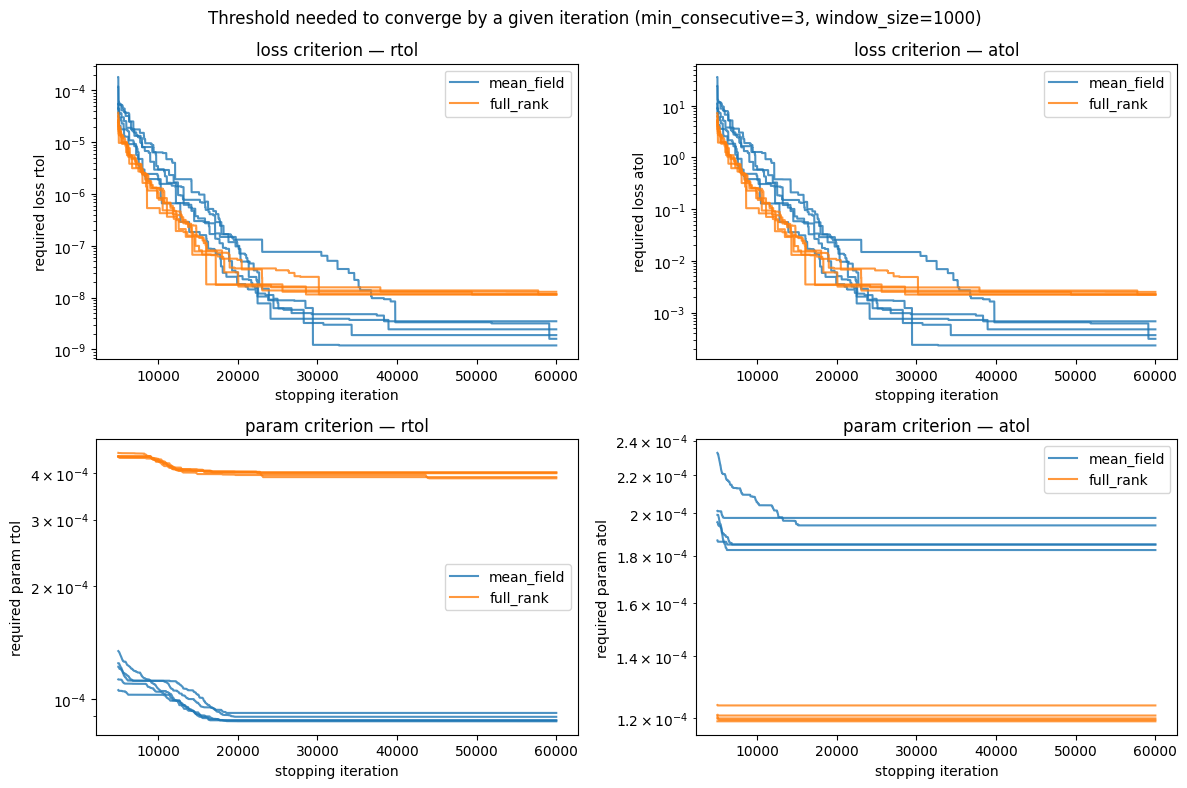

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, (target, kind, _) in zip(axes.ravel(), CRITERIA):
    for r in runs:
        wmax, frontier = r["frontiers"][(target, kind)]
        finite = np.isfinite(frontier)
        ax.plot(np.arange(len(frontier))[finite], frontier[finite],
                color=colors[r["family"]], alpha=0.8,
                label=r["family"] if r["seed"] == 0 else None)
    ax.set_yscale("log")
    ax.set_xlabel("stopping iteration")
    ax.set_ylabel(f"required {target} {kind}")
    ax.set_title(f"{target} criterion — {kind}")
    ax.legend()
fig.suptitle(
    f"Threshold needed to converge by a given iteration "
    f"(min_consecutive={MIN_CONSECUTIVE}, window_size={WINDOW_SIZE})"
)
fig.tight_layout()
plt.show()

### Summary: thresholds that achieve a target stopping iteration

For each run we read the frontier at a few target stopping iterations (as a
fraction of the run) — i.e. *the loosest `rtol`/`atol` that would have made this
run converge by that point*. The last column (`by 100%`) is the threshold needed
to converge right at the final iteration; it is the smallest threshold that
converges within the budget at all.

In [11]:
fracs = [0.5, 0.75, 1.0]
rows = []
for r in runs:
    for target, kind, _ in CRITERIA:
        _, frontier = r["frontiers"][(target, kind)]
        row = {"family": r["family"], "seed": r["seed"],
               "criterion": f"{target} {kind}"}
        for f in fracs:
            t = int(f * NUM_STEPS) - 1
            val = frontier[t]
            row[f"by {int(f*100)}%"] = (np.nan if not np.isfinite(val) else val)
        rows.append(row)

summary = pd.DataFrame(rows)
pd.set_option("display.float_format", lambda v: f"{v:.3e}")
summary

,family,seed,criterion,by 50%,by 75%,by 100%
0,mean_field,0,loss rtol,3.918e-09,2.452e-09,2.452e-09
1,mean_field,0,loss atol,7.585e-04,4.747e-04,4.747e-04
2,mean_field,0,param rtol,8.758e-05,8.758e-05,8.758e-05
3,mean_field,0,param atol,1.941e-04,1.941e-04,1.941e-04
4,mean_field,1,loss rtol,4.804e-09,3.507e-09,3.507e-09
5,mean_field,1,loss atol,9.301e-04,6.790e-04,6.790e-04
6,mean_field,1,param rtol,9.169e-05,9.169e-05,9.169e-05
7,mean_field,1,param atol,1.851e-04,1.851e-04,1.851e-04
8,mean_field,2,loss rtol,3.249e-09,1.896e-09,1.896e-09
9,mean_field,2,loss atol,6.290e-04,3.670e-04,3.670e-04


### Inverse view: where would a chosen threshold have stopped each run?

Picking concrete `rtol`/`atol` values, at which iteration would each run have
stopped? Empty cells (`—`) mean that threshold never fired within the
`NUM_STEPS` budget.

In [12]:
CANDIDATES = {
    ("loss", "rtol"): [1e-4, 1e-5, 1e-6, 1e-7],
    ("loss", "atol"): [1e1, 1e0, 1e-1, 1e-2],
    ("param", "rtol"): [1e-3, 1e-4, 1e-5, 1e-6],
    ("param", "atol"): [1e-3, 1e-4, 1e-5, 1e-6],
}

rows = []
for r in runs:
    for (target, kind), thresholds in CANDIDATES.items():
        wmax, _ = r["frontiers"][(target, kind)]
        row = {"family": r["family"], "seed": r["seed"],
               "criterion": f"{target} {kind}"}
        for T in thresholds:
            stop = stop_iteration(wmax, T, min_num_steps=MIN_NUM_STEPS)
            row[f"{T:.0e}"] = "—" if stop is None else stop
        rows.append(row)

inverse = pd.DataFrame(rows)
inverse

,family,seed,criterion,1e-04,1e-05,1e-06,1e-07,1e+01,1e+00,1e-01,1e-02,1e-03
0,mean_field,0,loss rtol,5000,6901,10324,1.627e+04,NaN,NaN,NaN,NaN,NaN
1,mean_field,0,loss atol,NaN,NaN,NaN,NaN,5.000e+03,7.557e+03,1.278e+04,1.788e+04,NaN
2,mean_field,0,param rtol,11969,—,—,NaN,NaN,NaN,NaN,NaN,5.000e+03
3,mean_field,0,param atol,—,—,—,NaN,NaN,NaN,NaN,NaN,5.000e+03
4,mean_field,1,loss rtol,5013,7967,15136,1.971e+04,NaN,NaN,NaN,NaN,NaN
5,mean_field,1,loss atol,NaN,NaN,NaN,NaN,5.537e+03,1.102e+04,1.692e+04,2.040e+04,NaN
6,mean_field,1,param rtol,13802,—,—,NaN,NaN,NaN,NaN,NaN,5.000e+03
7,mean_field,1,param atol,—,—,—,NaN,NaN,NaN,NaN,NaN,5.000e+03
8,mean_field,2,loss rtol,5001,6256,12226,1.813e+04,NaN,NaN,NaN,NaN,NaN
9,mean_field,2,loss atol,NaN,NaN,NaN,NaN,5.002e+03,7.456e+03,1.466e+04,1.890e+04,NaN


## Takeaways

- The frontier curves quantify the trade-off between a tighter threshold and a
  later stopping iteration for each criterion and approximation family.
- `min_consecutive` matters: because the back-calculation uses the trailing
  *maximum* over the window, a single noisy spike pushes the required threshold
  up for `min_consecutive` iterations — exactly the spurious early-stop that
  `min_consecutive` is designed to prevent.
- The `min_num_steps` warm-up guard matters just as much: the EWMA starts at 0
  and is biased low for the first $\sim$`window_size` steps, so without the guard
  almost any loose threshold "converges" within the first `min_consecutive`-step
  window. This is why the default criterion pairs a large `window_size` with an
  even larger `min_num_steps`.
- The sampled parameter trajectories show *which* variables are still drifting
  late in optimisation — often the most informative being the tree's root and
  internal node heights, which settle later than the substitution parameters.
- Comparing `mean_field` vs `full_rank` shows whether the richer full-rank
  approximation needs looser or tighter thresholds (and more iterations) to be
  judged converged on this dataset.
- For parameters whose optimum may sit near zero, the `param atol` frontier is
  the relevant one: the `param rtol` diagnostic (which divides by
  `rms(theta)`) can fail to settle there, as discussed in
  `LossAndParametersNotChanging`.